# The Capstone: Healthcare Insurance Claim Approval Agent
- Build an automated claim validation system that can process complex medical records and insurance policies
- Implement a multi-tool ReAct agent architecture using LangChain and LangGraph
- Achieve human-level accuracy in insurance claim decision-making
- Provide transparent, explainable decisions with detailed reasoning
- Demonstrate real-world application of AI in healthcare insurance workflows

## 🔧 Technical Stack
- **AI Framework**: LangChain & LangGraph for agent orchestration
- **Language Model**: Azure OpenAI GPT-4 for intelligent reasoning
- **Data Processing**: Python, pandas for structured data handling
- **Architecture**: ReAct (Reasoning + Acting) agent pattern with specialized tools


## Problem Statement
To build a robust, intelligent
insurance claim validation system using cutting-edge Agentic AI techniques and frameworks such as LangChain and
LangGraph.

An AI-powered agent system that can:
- Interpret semi-structured patient health records along with submitted insurance claims
- Perform retrieval and reasoning with relevant insurance policy guidelines
- Automate the insurance claim coverage decision-making process by generating contextually accurate and
well-justified outcomes, including auto-approvals or routing for manual review


## 🏗️ Solution Requirements & Technical Specifications

### Architecture Overview: ReAct Agent System
The solution implements a sophisticated **ReAct (Reasoning + Acting) Agent** architecture that combines planning, tool usage, and decision-making in a cohesive workflow.

### 🔧 Agent Architecture Workflow
The workflow diagram below illustrates how the ReAct Agent functions through a coordinated system of:
- **Single Intelligent Agent**: Central reasoning engine powered by Azure OpenAI GPT-4
- **Three Specialized Tools**: Domain-specific utilities for data processing and analysis
- **System Instruction Prompt**: Comprehensive guidelines ensuring consistent decision-making

### 📊 Detailed Workflow Process
1. **Data Ingestion**: Agent receives patient records and identifies relevant insurance policy
2. **Tool 1 - Patient Analysis**: Uses `summarize_patient_record` to extract and structure key medical information
3. **Tool 2 - Policy Analysis**: Uses `summarize_policy_guideline` to interpret coverage rules and restrictions  
4. **Tool 3 - Coverage Evaluation**: Uses `check_claim_coverage` to perform comprehensive eligibility assessment
5. **Decision Generation**: Produces final determination with detailed reasoning

### 🎯 Output Specifications
- **Binary Decision**: Either **APPROVE** or **ROUTE FOR REVIEW**
- **Detailed Reasoning**: Concise, evidence-based explanation referencing specific policy criteria
- **Audit Trail**: Complete record of tool usage and decision factors
- **Consistency**: Standardized format ensuring reproducible outcomes

### 📁 Development & Testing Data
- **Development Dataset**: `validation_records.json` - 10 cases for system development and refinement
- **Evaluation Dataset**: Human expert decisions for performance benchmarking
- **Production Dataset**: `test_records.json` - Final evaluation cases for submission
- **Output Format**: Results must be saved in `submission.csv` with patient_id and generated_response columns

### 🔍 Quality Assurance Process
- Compare agent decisions against human expert evaluations
- Analyze disagreement patterns to identify improvement opportunities  
- Iterative refinement based on performance metrics and edge case analysis
- Comprehensive testing across diverse medical scenarios and policy conditions
# ======================================================================
# Logical Architecture Diagram Display
# ======================================================================
# Load and display the system architecture diagram showing the ReAct agent


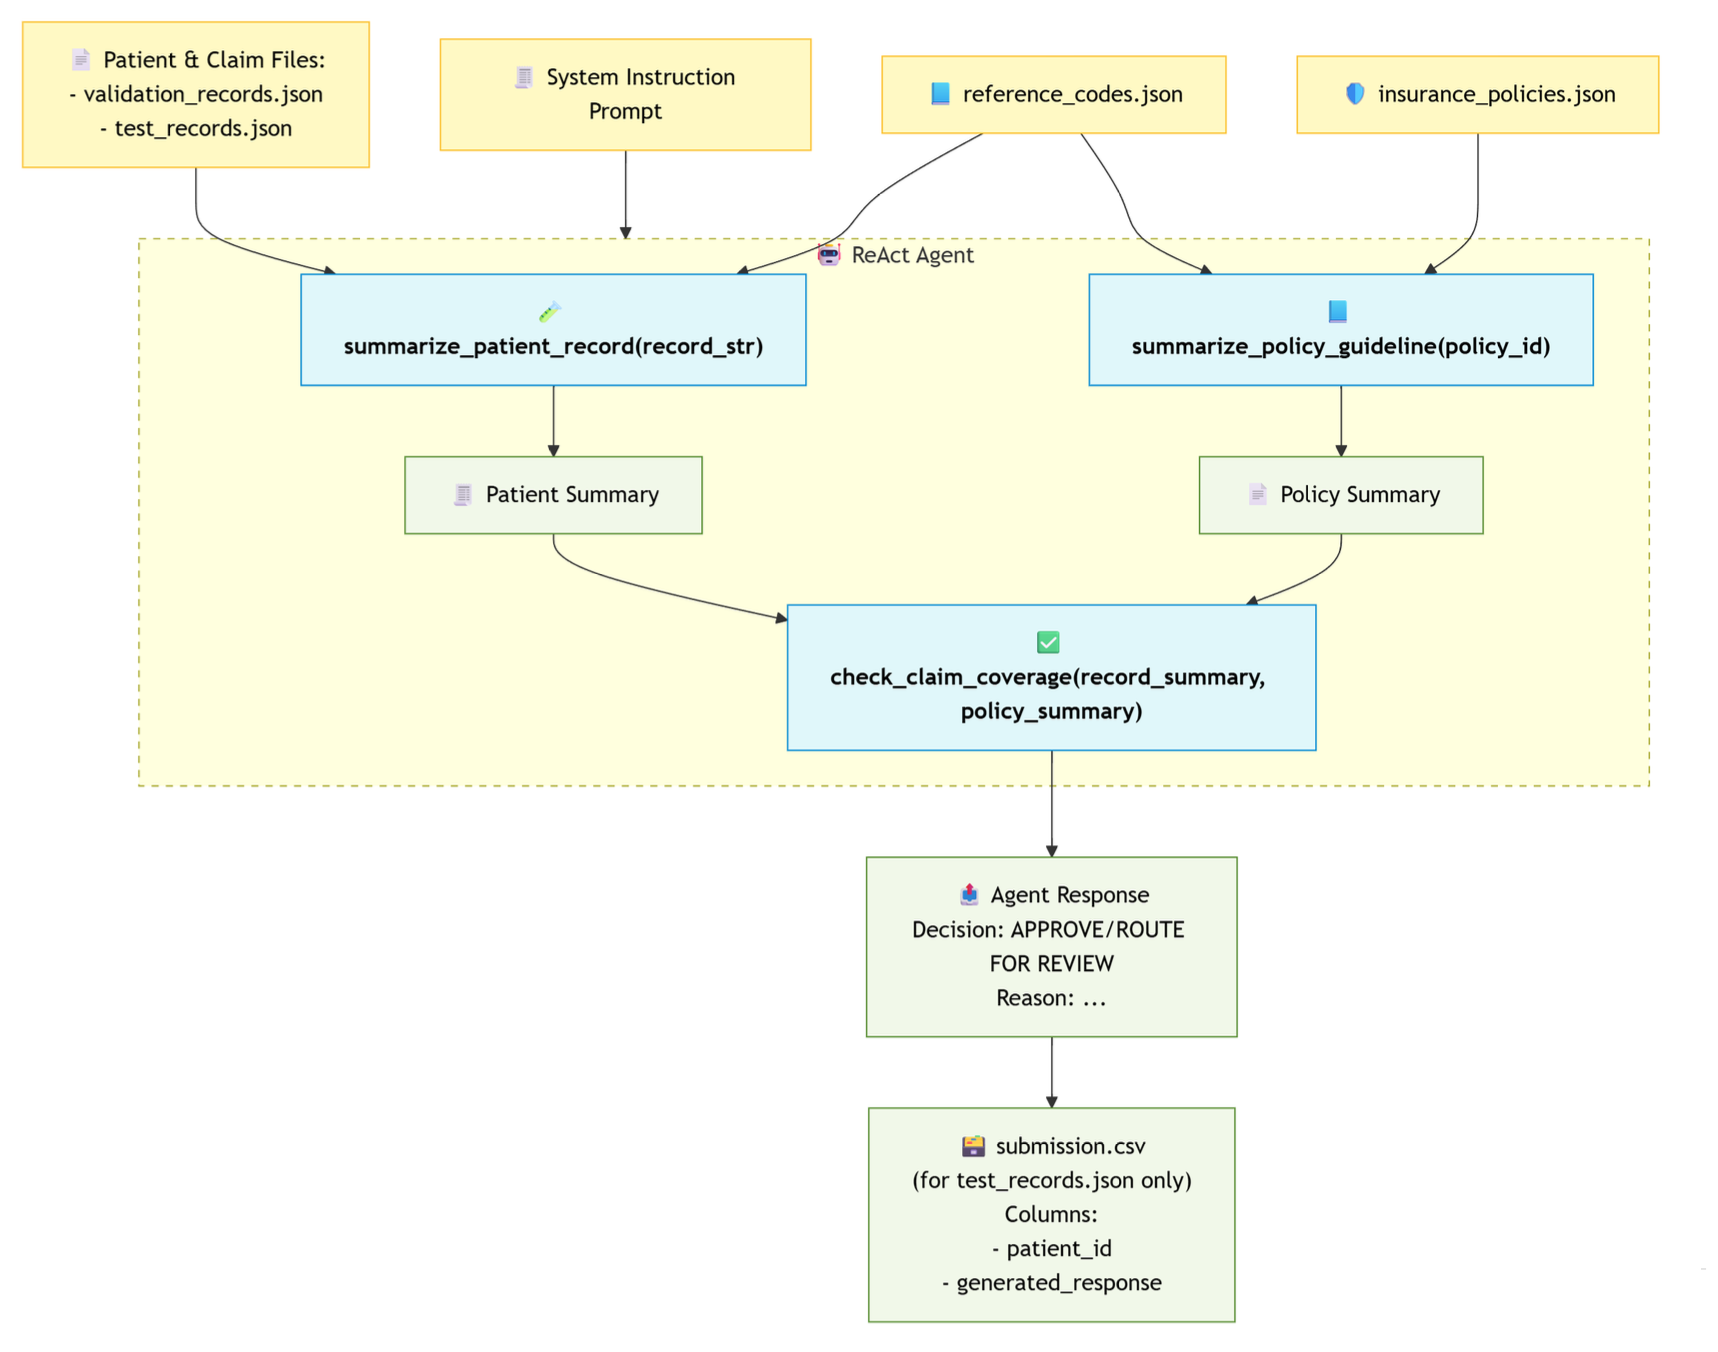

In [1]:
# workflow with three specialized tools for claim processing

from IPython.display import Image
Image(filename='/Users/csharm33/code/genai_dbx/Project/Data/claim_approver_agent_flow.png')


## 🔧 Initializing Development Environment

### Environment Setup Overview
This section establishes the foundational development environment required for the healthcare insurance claim approval agent. 


In [2]:
#%run /Users/csharm33/code/genai_dbx/Project/.setup/learner_setup.ipynb


## 📦 Load Essential Dependencies & Libraries

### Core Framework Imports
This section imports all essential libraries and frameworks required for building the intelligent insurance claim approval agent.
# ======================================================================
# Core Framework Imports for Healthcare Insurance Claim Agent
# ======================================================================
# Import all essential libraries and frameworks for building the intelligent
# insurance claim approval agent using LangChain, LangGraph, and Azure OpenAI


In [3]:
# Standard library for JSON data processing
import json

# Azure OpenAI integration for LLM capabilities
from langchain_openai import AzureChatOpenAI      # Primary reasoning engine
from langchain_openai import AzureOpenAIEmbeddings # Vector embeddings for semantic analysis

# LangChain core components for agent architecture
from langchain_core.tools import tool              # Decorator for creating agent tools
from typing import Annotated                       # Type annotations for structured data
from typing_extensions import TypedDict            # Enhanced typing for agent state management

# LangGraph components for ReAct agent implementation
from langgraph.graph.message import add_messages   # Message flow management
from langchain_core.messages import SystemMessage, HumanMessage # Message types for LLM interaction
from langgraph.prebuilt import create_react_agent  # Factory for building ReAct agents

# IPython display utilities for rich notebook output
from IPython.display import display, Image, Markdown # Interactive content rendering


## 🔐 Setup Authentication & Azure OpenAI Client Configuration

### Enterprise Authentication System
This section implements secure authentication and client initialization for Azure OpenAI services using enterprise-grade security protocols.

#### Authentication Flow
1. **Environment Variable Loading**: Securely loads credentials from `.env` file
2. **Token Acquisition**: Exchanges client credentials for access token via OAuth 2.0
3. **Client Initialization**: Configures both LLM and embedding clients with authentication

#### Azure OpenAI Client Setup
- **`AzureChatOpenAI`**: Primary reasoning engine for claim analysis and decision-making
  - Temperature: 0 (deterministic outputs for consistency)
  - Model: GPT-4 deployment for advanced reasoning capabilities
- **`AzureOpenAIEmbeddings`**: Vector embeddings for semantic similarity and document retrieval
  - Optimized for medical terminology and insurance policy language


In [4]:
# ======================================================================
# Azure OpenAI Authentication & Client Configuration
# ======================================================================
# Implement enterprise-grade authentication using UnitedHealth's UAIS platform
# and configure Azure OpenAI clients for both chat and embedding services

import os
from dotenv import load_dotenv
import httpx

def get_access_token():
    """
    Acquire OAuth 2.0 access token using client credentials flow.
    
    This function implements the standard OAuth 2.0 client credentials grant
    to authenticate with UnitedHealth's UAIS (Authentication & Identity Services)
    platform for secure API access.
    
    Returns:
        str: Valid access token for Azure OpenAI API calls
    """
    auth = "https://api.uhg.com/oauth2/token"
    scope = "https://api.uhg.com/.default"
    grant_type = "client_credentials"


    with httpx.Client() as client:
        body = {
            "grant_type": grant_type,
            "scope": scope,
            "client_id": client_id,
            "client_secret": client_secret,
        }
        headers = {"Content-Type": "application/x-www-form-urlencoded"}
        resp = client.post(auth, headers=headers, data=body, timeout=60)
        access_token = resp.json()["access_token"]
        return access_token

# Load environment variables securely from .env file
# Contains sensitive credentials that must not be hardcoded
load_dotenv('/Users/csharm33/code/genai_dbx/Project/Data/vars.env')

# Extract authentication and configuration parameters from environment

AZURE_OPENAI_ENDPOINT = os.environ["AZURE_OPENAI_ENDPOINT"]
OPENAI_API_VERSION = os.environ["OPENAI_API_VERSION"]
EMBEDDINGS_DEPLOYMENT_NAME = os.environ["EMBEDDINGS_DEPLOYMENT_NAME"]
MODEL_DEPLOYMENT_NAME = os.environ["MODEL_DEPLOYMENT_NAME"]
PROJECT_ID = os.environ['PROJECT_ID']
client_id = os.environ.get("CLIENT_ID")
client_secret = os.environ.get("CLIENT_SECRET")

# Initialize Azure OpenAI Chat Client (Primary reasoning engine)
chat_client = AzureChatOpenAI(
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_version=OPENAI_API_VERSION,
    azure_deployment = MODEL_DEPLOYMENT_NAME,
    temperature=0,
    azure_ad_token=get_access_token(),
    default_headers={
        "projectId": PROJECT_ID
    }
)

# Initialize Azure OpenAI Embeddings Client (Semantic analysis engine)
embeddings_client = AzureOpenAIEmbeddings(
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_version=OPENAI_API_VERSION,
    azure_deployment=EMBEDDINGS_DEPLOYMENT_NAME,
    azure_ad_token=get_access_token(),
    default_headers={
        "projectId": PROJECT_ID
    }
)

## 📚 Load Healthcare Insurance Datasets & Reference Materials

### Dataset Overview
This section loads comprehensive healthcare and insurance datasets that serve as the knowledge base for the claim approval agent. The data simulates real-world insurance operations while maintaining privacy and security.

### 🏥 Core Datasets

#### 1. **Insurance Policies** (`insurance_policies.json`)
- **Comprehensive Coverage Rules**: Detailed policy guidelines including covered procedures, diagnoses, and restrictions
- **Age & Gender Restrictions**: Specific demographic requirements for procedure coverage
- **Preauthorization Requirements**: Rules determining when prior approval is needed

#### 2. **Medical Reference Codes** (`reference_codes.json`)
- **ICD-10 Diagnosis Codes**: International Classification of Diseases for precise medical condition identification
- **CPT Procedure Codes**: Current Procedural Terminology for standardized medical procedure classification

#### 3. **Validation Records** (`validation_records.json`)
- **Development Dataset**: 10 carefully curated patient cases for agent development and testing
- **Diverse Scenarios**: Range of medical conditions, age groups, and complexity levels
- **Edge Cases**: Challenging scenarios that test agent decision-making capabilities

#### 4. **Test Records** (`test_records.json`)
- **Production Evaluation**: Final test cases for agent performance assessment
- **Real-World Complexity**: Authentic healthcare scenarios reflecting actual claim submissions

### 🎯 Integration Strategy
These datasets integrate seamlessly with the three specialized agent tools:
- **Tool 1**: Patient record analysis leverages medical code references
- **Tool 2**: Policy interpretation uses comprehensive coverage rules
- **Tool 3**: Coverage evaluation combines all datasets for informed decisions
# ======================================================================
# Healthcare Insurance Dataset Loading
# ======================================================================
# Load comprehensive datasets that serve as the knowledge base for the 
# intelligent claim approval agent, including policies, medical codes, 
# and patient records for development and testing


In [5]:
# Load insurance policy guidelines and coverage rules
with open('/Users/csharm33/code/genai_dbx/Project/Data/insurance_policies.json', 'r') as f:
    insurance_policies_data = json.load(f)

# Load medical reference codes (ICD-10 diagnoses and CPT procedures)
# Essential for translating medical codes to human-readable descriptions
with open('/Users/csharm33/code/genai_dbx/Project/Data/reference_codes.json', 'r') as f:
    reference_codes_data = json.load(f)

# Load test records for final agent evaluation and submission
with open('/Users/csharm33/code/genai_dbx/Project/Data/test_records.json', 'r') as f:
    test_records_data = json.load(f)

# Load validation records for development and performance benchmarking
# Used to compare agent decisions against human expert evaluations
with open('/Users/csharm33/code/genai_dbx/Project/Data/validation_records.json', 'r') as f:
    validation_records_data = json.load(f)    

# Display the structure of medical reference data for verification
# Shows available code categories (ICD10 diagnoses, CPT procedures, etc.)
print(f"Major Document Types: {list(reference_codes_data.keys())}")


Major Document Types: ['CPT', 'ICD10']


## Age Calculation Utilities for Healthcare Context
### Clinical Age Calculation Importance
In healthcare insurance, precise age calculation is critical for:
- **Policy Eligibility**: Many procedures have strict age ranges for coverage
- **Risk Assessment**: Age-based clinical guidelines affect approval decisions  
- **Regulatory Compliance**: Accurate age reporting required for audit trails
- **Cost Management**: Age-adjusted premium calculations and coverage tiers

### 🔧 Utility Functions Overview

#### `calculate_age_at_service(date_of_birth, date_of_service)`
**Purpose**: Calculates patient's exact age at the time medical service was provided
- **Precision**: Accounts for whether birthday occurred before service date
- **Healthcare Standard**: Follows medical industry practices for age determination
- **Edge Case Handling**: Manages leap years, month boundaries, and date parsing errors

#### `get_patient_age_at_service(patient_record)`
**Purpose**: Comprehensive age analysis providing multiple age contexts
- **Age at Service**: Patient age when medical procedure was performed (critical for coverage decisions)
- **Current Age**: Patient age as of today (useful for ongoing care considerations)
- **Validation**: Robust error handling for missing or invalid date formats
# ======================================================================
# Healthcare Age Calculation Utilities
# ======================================================================
# Specialized functions for precise age calculation in healthcare insurance context


In [6]:
# Critical for determining policy eligibility based on age-specific coverage rules

def calculate_age_at_service(date_of_birth: str, date_of_service: str) -> int:
    """
    Calculate patient's exact age at the time medical service was provided.
    
    This function is critical for healthcare insurance as many procedures have
    strict age ranges for coverage eligibility. It accounts for whether the
    patient's birthday had occurred before the service date in the same year.
    
    Args:
        date_of_birth (str): Patient's date of birth in format 'YYYY-MM-DD'
        date_of_service (str): Date of service in format 'YYYY-MM-DD'
    
    Returns:
        int: Patient's age at time of service, or None if calculation fails
        
    Example:
        >>> calculate_age_at_service('1990-06-15', '2023-03-10')
        32  # Patient was 32 at service date (birthday not yet reached in 2023)
    """
    try:
        from datetime import datetime
        
        # Parse date strings into datetime objects for precise calculation
        birth_date = datetime.strptime(date_of_birth, '%Y-%m-%d')
        service_date = datetime.strptime(date_of_service, '%Y-%m-%d')
        
        # Extract years for initial age calculation
        birth_year = birth_date.year
        service_year = service_date.year
        
        # Calculate preliminary age (service year - birth year)
        age = service_year - birth_year
        
        # Adjust age if birthday hasn't occurred yet in the service year
        # Compare month and day to determine if birthday passed
        if (birth_date.month, birth_date.day) > (service_date.month, service_date.day):
            age -= 1  # Subtract 1 if birthday hasn't occurred yet
        
        return age
        
    except (ValueError, AttributeError) as e:
        # Return None for invalid date formats or parsing errors
        # Allows graceful handling of malformed data
        return None

def get_patient_age_at_service(patient_record: dict) -> dict:
    """
    Comprehensive age analysis for patient records in healthcare context.
    
    Extracts birth date and service date from patient record and calculates
    both age at service (critical for coverage decisions) and current age
    (useful for ongoing care considerations).
    
    Args:
        patient_record (dict): Patient record containing date_of_birth and date_of_service
    
    Returns:
        dict: Comprehensive age information including:
            - date_of_birth: Original birth date from record
            - date_of_service: Original service date from record  
            - age_at_service: Age when medical procedure was performed
            - current_age: Patient's current age as of today
            
    Example:
        >>> patient = {'date_of_birth': '1985-12-01', 'date_of_service': '2023-06-15'}
        >>> get_patient_age_at_service(patient)
        {'date_of_birth': '1985-12-01', 'date_of_service': '2023-06-15', 
         'age_at_service': 37, 'current_age': 38}
    """
    # Extract date information from patient record with safe defaults
    dob = patient_record.get('date_of_birth')
    service_date = patient_record.get('date_of_service')
    
    # Initialize age information structure
    age_info = {
        'date_of_birth': dob,
        'date_of_service': service_date,
        'age_at_service': None,      # Age when procedure was performed
        'current_age': None          # Current age as of today
    }
    
    # Calculate ages only if both dates are available
    if dob and service_date:
        # Calculate age at time of service (critical for coverage decisions)
        age_info['age_at_service'] = calculate_age_at_service(dob, service_date)
        
        # Calculate current age for reference and ongoing care considerations
        from datetime import datetime
        current_date = datetime.now().strftime('%Y-%m-%d')
        age_info['current_age'] = calculate_age_at_service(dob, current_date)
    
    return age_info


## 🛠️ Specialized Agent Tools: The Foundation of Intelligent Claim Processing

### Tool Architecture Overview
The healthcare insurance claim approval agent operates through three specialized tools that work in concert to provide comprehensive claim analysis. Each tool has a specific role in the decision-making process, following the ReAct (Reasoning + Acting) pattern for systematic claim evaluation.

### 🔧 Tool Integration Strategy
These tools implement a **mandatory sequential workflow** that ensures:
- **Comprehensive Analysis**: Each tool builds upon the previous tool's output
- **Consistent Decision-Making**: Standardized process eliminates variability
- **Audit Compliance**: Complete trail of analysis steps for regulatory review
- **Quality Assurance**: Multi-step validation reduces error probability

---

## 📋 Tool 1: Patient Record Summarization Engine
**Function**: `summarize_patient_record(record_str)`

### Purpose & Capabilities
Transforms raw patient records into structured, analysis-ready summaries that serve as the foundation for all subsequent decision-making.

### Key Features
- **Demographic Extraction**: Patient name, age, gender with clinical context
- **Medical Code Translation**: Converts ICD-10 and CPT codes to human-readable descriptions
- **Policy Integration**: Links patient records to relevant insurance policy information
- **Preauthorization Status**: Analyzes authorization requirements and compliance
- **Financial Context**: Provides billed amount information for cost considerations

---

## 📖 Tool 2: Policy Guideline Intelligence System  
**Function**: `summarize_policy_guideline(policy_id)`

### Purpose & Capabilities
Interprets complex insurance policy documents and generates structured coverage summaries that enable accurate eligibility determination.

### Key Features
- **Coverage Mapping**: Detailed procedure-to-diagnosis coverage relationships
- **Restriction Analysis**: Age ranges, gender requirements, and special conditions
- **Authorization Rules**: Preauthorization requirements and approval processes
- **Clinical Guidelines**: Medical necessity criteria and evidence requirements
- **Exception Handling**: Special coverage rules and appeal processes

---

## ⚖️ Tool 3: Comprehensive Coverage Evaluation Engine
**Function**: `check_claim_coverage(record_summary, policy_summary)`

### Purpose & Capabilities
Performs the final coverage determination by analyzing patient records against policy guidelines using advanced LLM reasoning capabilities.

### Key Features
- **Multi-Criteria Analysis**: Evaluates diagnosis alignment, age eligibility, gender restrictions
- **Risk Assessment**: Identifies potential coverage issues requiring manual review
- **Decision Logic**: Applies complex business rules with explainable reasoning
- **Compliance Validation**: Ensures decisions meet regulatory and policy requirements
- **Audit Trail Generation**: Creates detailed documentation for decision justification

# ======================================================================
# Specialized Agent Tools: Three-Tool Healthcare Claim Processing Pipeline
# ======================================================================
# Implementation of three specialized tools that work sequentially to analyze
# insurance claims using the ReAct (Reasoning + Acting) agent pattern

# ======================================================================
# TOOL 1: Patient Record Summarization Engine


In [7]:
# ======================================================================
@tool
def summarize_patient_record(record_str: str) -> str:
    """
    Extract and structure patient insurance claim information into analysis-ready format.
    
    This tool serves as the foundation of the claim analysis pipeline, transforming
    raw patient records into structured summaries that enable intelligent decision-making.
    It handles medical code translation, age calculation, and preauthorization analysis.
    
    Args:
        record_str (str): Raw patient record as JSON string or dictionary
    
    Returns:
        str: Structured summary with seven standardized sections:
            - Patient Demographics (name, gender, calculated age)
            - Insurance Policy ID (for policy lookup)
            - Diagnoses with ICD-10 code translations
            - Procedures with CPT code translations  
            - Preauthorization Status (required/obtained analysis)
            - Billed Amount (financial context)
            - Date of Service (temporal context)
    
    Key Features:
        - Automatic medical code translation using reference data
        - Precise age calculation at time of service
        - Preauthorization compliance checking
        - Error handling for malformed data
    """
    try:
        # Parse input record - handle both string and dict formats
        if isinstance(record_str, str) and record_str.strip().startswith('{'):
            record = json.loads(record_str)
        else:
            record = record_str if isinstance(record_str, dict) else json.loads(record_str)
        
        # Calculate precise age at time of service (critical for eligibility)
        age_info = get_patient_age_at_service(record)
        age_at_service = age_info.get('age_at_service', 'Unknown')
        
        # Translate ICD-10 diagnosis codes to human-readable descriptions
        # Essential for understanding medical context and policy matching
        diagnosis_descriptions = []
        for code in record.get('diagnosis_codes', []):
            description = reference_codes_data.get('ICD10', {}).get(code, 'Unknown diagnosis')
            diagnosis_descriptions.append(f"{code}: {description}")
        
        # Translate CPT procedure codes to human-readable descriptions
        # Critical for identifying what medical services were performed
        procedure_descriptions = []
        for code in record.get('procedure_codes', []):
            description = reference_codes_data.get('CPT', {}).get(code, 'Unknown procedure')
            procedure_descriptions.append(f"{code}: {description}")
        
        # Analyze preauthorization requirements and compliance
        # Many procedures require prior approval for coverage
        preauth_required = record.get('preauthorization_required', False)
        preauth_obtained = record.get('preauthorization_obtained', False)
        
        if preauth_required:
            preauth_status = f"Required: Yes, Obtained: {'Yes' if preauth_obtained else 'No'}"
        else:
            preauth_status = "Required: No"
        
        # Generate structured summary in standardized format
        summary = f"""
Patient Demographics:
- Name: {record.get('name', 'Unknown')}
- Gender: {record.get('gender', 'Unknown')}
- Age: {age_at_service}

Insurance Policy ID: {record.get('insurance_policy_id', 'Unknown')}

Diagnoses and Descriptions:
{chr(10).join(f"- {desc}" for desc in diagnosis_descriptions) if diagnosis_descriptions else "- None listed"}

Procedures and Descriptions:
{chr(10).join(f"- {desc}" for desc in procedure_descriptions) if procedure_descriptions else "- None listed"}

Preauthorization Status: {preauth_status}

Billed Amount (in USD): ${record.get('billed_amount', 0):,.2f}

Date of Service: {record.get('date_of_service', 'Unknown')}
        """.strip()
        
        return summary
        
    except Exception as e:
        # Graceful error handling to prevent agent failures
        return f"Error processing patient record: {str(e)}"


# ======================================================================
# TOOL 2: Policy Guideline Intelligence System
# ======================================================================
@tool
def summarize_policy_guideline(policy_id: str) -> str:
    """
    Generate structured summary of insurance policy coverage rules and restrictions.
    
    This tool interprets complex insurance policy documents and creates analysis-ready
    summaries that enable accurate coverage determination. It handles procedure-diagnosis
    mapping, age/gender restrictions, and preauthorization requirements.
    
    Args:
        policy_id (str): Insurance policy identifier to retrieve and analyze
    
    Returns:
        str: Structured policy summary containing:
            - Policy Details (ID and plan name)
            - Covered Procedures (with full specifications)
            - For each procedure:
                * CPT code and translated description
                * Covered diagnoses (ICD-10 codes with descriptions)
                * Gender restrictions (if any)
                * Age range requirements
                * Preauthorization requirements
                * Special coverage notes
    
    Key Features:
        - Automatic medical code translation for clarity
        - Comprehensive coverage rule extraction
        - Age and gender restriction analysis
        - Preauthorization requirement identification
    """
    try:
        # Search for the specified policy in the loaded dataset
        policy = None
        for pol in insurance_policies_data:
            if pol.get('policy_id') == policy_id:
                policy = pol
                break
        
        # Handle case where policy is not found
        if not policy:
            return f"Policy {policy_id} not found in the dataset."
        
        # Initialize policy summary with basic information
        summary = f"""
Policy Details:
- Policy ID: {policy.get('policy_id', 'Unknown')}
- Plan Name: {policy.get('plan_name', 'Unknown')}

Covered Procedures:
"""
        
        # Process each covered procedure with full detail extraction
        for i, procedure in enumerate(policy.get('covered_procedures', []), 1):
            # Get procedure code and translate to description
            proc_code = procedure.get('procedure_code', 'Unknown')
            proc_description = reference_codes_data.get('CPT', {}).get(proc_code, 'Unknown procedure')
            
            summary += f"\n{i}. Procedure Code and Description: {proc_code} - {proc_description}\n"
            
            # Extract and translate covered diagnoses
            covered_diagnoses = procedure.get('covered_diagnoses', [])
            summary += "   Covered Diagnoses and Descriptions:\n"
            for diag_code in covered_diagnoses:
                diag_description = reference_codes_data.get('ICD10', {}).get(diag_code, 'Unknown diagnosis')
                summary += f"   - {diag_code}: {diag_description}\n"
            
            # Extract coverage restrictions and requirements
            gender_restriction = procedure.get('gender', 'Any')
            age_range = procedure.get('age_range', [])
            age_range_str = f"{age_range[0]}-{age_range[1]}" if len(age_range) == 2 else "Not specified"
            preauth_req = "Yes" if procedure.get('requires_preauthorization', False) else "No"
            notes = procedure.get('notes', 'None')
            
            # Add restriction details to summary
            summary += f"   Gender Restriction: {gender_restriction}\n"
            summary += f"   Age Range: {age_range_str}\n"
            summary += f"   Preauthorization Requirement: {preauth_req}\n"
            summary += f"   Notes on Coverage: {notes}\n"
        
        return summary.strip()
        
    except Exception as e:
        # Graceful error handling to prevent agent failures
        return f"Error processing policy guidelines: {str(e)}"


# ======================================================================
# TOOL 3: Comprehensive Coverage Evaluation Engine
# ======================================================================
@tool
def check_claim_coverage(record_summary: str, policy_summary: str) -> str:
    """
    Perform final coverage determination using advanced LLM reasoning.
    
    This tool represents the culmination of the three-tool pipeline, applying
    sophisticated reasoning to determine claim coverage eligibility. It evaluates
    all aspects of the claim against policy requirements and generates evidence-based
    decisions with detailed justification.
    
    Args:
        record_summary (str): Structured patient record summary from Tool 1
        policy_summary (str): Structured policy guidelines summary from Tool 2
    
    Returns:
        str: Coverage decision with detailed reasoning:
            - APPROVED: All criteria met with supporting evidence
            - MANUAL REVIEW: Criteria unclear, missing, or requiring human expertise
            - Detailed reasoning explaining the decision basis
    
    Evaluation Criteria:
        1. Diagnosis-procedure alignment (ICD-10 to CPT matching)
        2. Procedure coverage verification (explicitly listed in policy)
        3. Age eligibility (within policy age ranges)
        4. Gender restrictions compliance
        5. Preauthorization requirements fulfillment
    
    Key Features:
        - Multi-criteria analysis using GPT-4 reasoning
        - Strict evaluation standards for consistency
        - Evidence-based decision making
        - Detailed audit trail generation
    """
    try:
        # Define comprehensive system prompt for LLM evaluation
        system_prompt = """You are an insurance claim evaluator. Analyze the patient record and policy guidelines to determine coverage eligibility.

Coverage Evaluation Criteria - A procedure should be APPROVED only if ALL conditions are met:
1. Patient's diagnosis code(s) match the policy-covered diagnoses for the claimed procedure
2. The procedure code is explicitly listed in the policy with all conditions satisfied
3. Patient's age falls within policy's age range (inclusive lower bound, exclusive upper bound)
4. Patient's gender matches the policy requirement for that procedure
5. If preauthorization is required by policy, it must have been obtained

Return your decision as either:
- APPROVED: [brief reason for approval]
- MANUAL REVIEW: [specific reason why manual review is needed]

Be strict in your evaluation - if any condition is not met, route to manual review."""

        # Construct user prompt with patient and policy information
        user_prompt = f"""
PATIENT RECORD SUMMARY:
{record_summary}

POLICY GUIDELINES SUMMARY:
{policy_summary}

Please evaluate this claim for coverage eligibility based on the criteria provided.
"""

        # Create message sequence for LLM interaction
        messages = [
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_prompt)
        ]
        
        # Invoke LLM for intelligent coverage evaluation
        response = chat_client.invoke(messages)
        return response.content
        
    except Exception as e:
        # Graceful error handling to prevent agent failures
        return f"Error evaluating claim coverage: {str(e)}"


## 🤖 Healthcare Insurance Claim Approval Agent: System Architecture

### Intelligent Agent Overview
The core of our solution is a sophisticated **ReAct (Reasoning + Acting) Agent** that combines advanced language model capabilities with specialized healthcare domain tools to make intelligent claim approval decisions.

### 🏗️ System Architecture Components

#### **Central Agent Engine**
- **LLM Foundation**: Powered by Azure OpenAI GPT-4 for advanced reasoning
- **ReAct Pattern**: Systematic approach combining planning, tool usage, and decision-making
- **State Management**: Maintains context across multiple tool interactions
- **Error Handling**: Robust failure recovery and graceful degradation

#### **Specialized Tool Ecosystem** 
The agent leverages three domain-specific tools in a mandatory sequence:

1. **📋 `summarize_patient_record`**
   - Extracts and structures patient medical information
   - Translates medical codes to human-readable descriptions
   - Calculates age-based eligibility factors

2. **📖 `summarize_policy_guideline`** 
   - Interprets complex insurance policy rules
   - Maps coverage requirements and restrictions
   - Identifies preauthorization and approval criteria

3. **⚖️ `check_claim_coverage`**
   - Performs comprehensive eligibility analysis  
   - Applies business rules and clinical guidelines
   - Generates evidence-based approval/review decisions

### 🎯 Decision Framework
The agent operates under strict decision criteria:
- **APPROVE**: All policy criteria clearly satisfied with supporting evidence
- **ROUTE FOR REVIEW**: Any criteria unclear, missing, or requiring human expertise
- **Transparent Reasoning**: Every decision includes detailed justification

# ======================================================================
# Healthcare Insurance Claim Approval Agent: System Integration
# ======================================================================
# Initialize the ReAct agent system that orchestrates the three specialized tools
# for intelligent insurance claim processing and decision-making

# ======================================================================
# Agent State Management
# ======================================================================
# Define the state structure for the ReAct agent using TypedDict


🤖 Healthcare Insurance Claim Approval System initialized with create_react_agent!


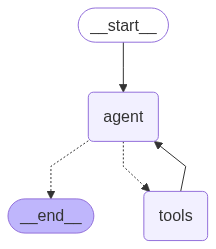

In [8]:
# This maintains conversation context and message history throughout the workflow
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]  # Message list with automatic aggregation

# ======================================================================
# Tool Registration and Configuration
# ======================================================================
# Register the three specialized tools in mandatory execution sequence
# Each tool builds upon the previous tool's output for comprehensive analysis
tools = [
    summarize_patient_record,    # Tool 1: Patient record analysis and structuring
    summarize_policy_guideline,  # Tool 2: Policy interpretation and rule extraction  
    check_claim_coverage        # Tool 3: Final coverage determination with LLM reasoning
]

# ======================================================================
# Agent System Prompt and Behavioral Instructions
# ======================================================================
# Comprehensive system prompt that defines the agent's role, workflow, and
# decision-making criteria for consistent and reliable claim processing
system_message = """You are an expert insurance claims analyst agent. Your task is to process insurance claims using a mandatory 3-tool sequence:

**MANDATORY WORKFLOW:**
1. FIRST: Use summarize_patient_record tool with the patient record data
2. SECOND: Use summarize_policy_guideline tool with the policy ID  
3. THIRD: Use check_claim_coverage tool with results from tools 1 and 2

**RESPONSE FORMAT:**
After step 3, provide your complete response in this exact format:
- Decision: [APPROVE or ROUTE FOR REVIEW]
- Reason: [Concise sentences explaining your decision based on policy criteria]

  Example: The claim for collecting venous blood by venipuncture (CPT code 36415) has been approved. This procedure is covered under the policy for the patient’s diagnosis of low back pain (M54.5). The patient is 14 years old, which falls within the covered age range of 11 to 27, and there are no gender-based restrictions. Preauthorization isn’t required, but it was obtained, and all policy requirements have been satisfied.
  Example: The claim for the procedure (CPT code 36415 - Collection of venous blood by venipuncture) cannot be automatically approved, as the patient’s age of 65 falls outside the allowed age range of 18 to 49 specified in the policy guidelines. Although the diagnosis (G43.909 – Migraine, unspecified, not intractable, without status migrainosus) and the procedure are covered, the age requirement is not met. As a result, the claim needs to be routed for further manual review.

**CRITICAL RULES:**
- You MUST use all three tools in the exact sequence above
- APPROVE only when ALL policy criteria are clearly met
- Use ROUTE FOR REVIEW when any criteria are not met or unclear
- Your response must include both Decision and Reason

Follow this workflow precisely for every claim."""

# ======================================================================
# ReAct Agent Initialization
# ======================================================================
# Create the ReAct (Reasoning + Acting) agent using LangGraph's prebuilt factory
# Integrates the chat client, specialized tools, and system instructions into
# a cohesive agent capable of sophisticated claim analysis
claim_approval_agent = create_react_agent(
    chat_client,        # Azure OpenAI GPT-4 client for reasoning capabilities
    tools,             # Three specialized healthcare claim processing tools
    prompt=system_message  # Comprehensive behavioral instructions and workflow rules
)

# ======================================================================
# System Initialization Confirmation
# ======================================================================
# Display confirmation of successful agent initialization with tool inventory
print("🤖 Healthcare Insurance Claim Approval System initialized with create_react_agent!")
# ======================================================================
# Langgraph Agent Architecture Diagram Display
# ======================================================================
# Load and display the system architecture diagram showing the ReAct agent
# workflow with three specialized tools for claim processing

from IPython.display import Image
Image(filename='/Users/csharm33/code/genai_dbx/Project/Data/claim_approver_agent_arch.png')


## 🔄 Agent Execution Utility

### Interactive Agent Execution Framework
This utility function provides a comprehensive interface for interacting with the claim approval agent, featuring real-time streaming of the agent's decision-making process and automated result management.

### 🎯 Core Functionality

#### **Real-Time Process Streaming**
- **Step-by-Step Visibility**: Watch the agent's reasoning process unfold in real-time
- **Tool Usage Tracking**: Monitor which tools are being called and their outputs
- **Decision Path Analysis**: Understand how the agent arrives at its final decision
- **Debugging Support**: Verbose mode for detailed troubleshooting and development

#### **Automated Result Management**
- **CSV Export**: Automatically writes results to submission.csv for batch processing
- **Patient ID Extraction**: Intelligent parsing of patient identifiers from queries
- **File Management**: Handles file creation, headers, and append operations
- **Error Recovery**: Graceful handling of processing failures with error logging

This utility serves as the primary interface between users and the intelligent claim approval agent, providing both transparency into the decision-making process and reliable automation for production environments.
# ======================================================================
# Agent Execution & Streaming Analysis Utility
# ======================================================================
# Comprehensive utility function for interacting with the claim approval agent


In [9]:
# Provides real-time streaming, result management, and automated CSV export

def call_claim_approval_agent(agent, query, verbose=False, patient_id=None, submission_file_name=None):
    """
    Execute the healthcare insurance claim approval agent with comprehensive logging.
    
    This function serves as the primary interface between users and the intelligent
    claim approval agent, providing both transparency into the decision-making process
    and reliable automation for production environments.
    
    Args:
        agent: The configured ReAct agent for claim processing
        query (str): Natural language query containing patient record information
        verbose (bool): Enable step-by-step reasoning display for debugging
        patient_id (str, optional): Patient identifier (auto-extracted if not provided)
        submission_file_name (str): Output CSV file path for results storage
    
    Returns:
        str: Final agent response with decision and reasoning
        
    Key Features:
        - Real-time agent execution streaming
        - Intelligent patient ID extraction from queries
        - Automated CSV export with proper headers
        - Rich markdown display formatting
        - Comprehensive error handling and recovery
    """
    import pandas as pd
    import csv
    import re

    # ======================================================================
    # Agent Execution with Real-Time Streaming
    # ======================================================================
    # Stream the agent's execution to provide visibility into the decision process
    # Each event represents a step in the ReAct workflow (reasoning + tool usage)
    for event in agent.stream(
        {"messages": [HumanMessage(content=query)]},  # Structured input message
        stream_mode='values'  # Stream intermediate values for transparency
    ):
        # Display detailed reasoning steps when verbose mode is enabled
        # Critical for debugging and understanding agent behavior
        if verbose:
            event["messages"][-1].pretty_print()

    # ======================================================================
    # Response Processing and Display
    # ======================================================================
    # Extract the final agent decision from the message stream
    final_response = event["messages"][-1].content

    # Display the agent's final decision in formatted markdown
    # Provides clear, professional output for end users
    print('\n\nFinal Response:\n')
    display(Markdown(final_response))

    # ======================================================================
    # Intelligent Patient ID Extraction
    # ======================================================================
    # Automatically extract patient identifier from various query formats
    # Supports both structured JSON and natural language inputs
    if patient_id is None:
        # Method 1: Extract from natural language patterns (e.g., "patient ABC123")
        patient_id_match = re.search(r'patient\s+([A-Z0-9_]+)', query, re.IGNORECASE)
        if patient_id_match:
            patient_id = patient_id_match.group(1)
        else:
            # Method 2: Extract from JSON structure in query
            try:
                import json
                # Search for JSON pattern containing patient_id field
                json_match = re.search(r'\{.*?"patient_id":\s*"([^"]+)".*?\}', query, re.DOTALL)
                if json_match:
                    json_str = json_match.group(0)
                    data = json.loads(json_str)
                    patient_id = data.get('patient_id', 'UNKNOWN')
                else:
                    patient_id = 'UNKNOWN'
            except:
                # Fallback for malformed JSON or extraction failures
                patient_id = 'UNKNOWN'

    # ======================================================================
    # CSV Export and File Management
    # ======================================================================
    # Automatically save results to CSV file for batch processing and analysis
    submission_file = submission_file_name
    
    # Check file existence and header requirements
    file_exists = os.path.exists(submission_file)
    write_header = not file_exists
    
    if file_exists:
        # Verify existing file has proper headers
        try:
            with open(submission_file, 'r', newline='', encoding='utf-8') as f:
                first_line = f.readline().strip()
                if not first_line or first_line != 'patient_id,generated_response':
                    write_header = True  # Re-write header if missing or incorrect
        except:
            write_header = True  # Handle file read errors

    # Write results to CSV with proper error handling
    try:
        with open(submission_file, 'a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            
            # Write standardized header row if needed
            if write_header:
                writer.writerow(['patient_id', 'generated_response'])
            
            # Append patient result data
            writer.writerow([patient_id, final_response])
            
        print(f"\n✅ Results written to submission.csv for patient: {patient_id}")
        
    except Exception as e:
        print(f"\n❌ Error writing to submission.csv: {str(e)}")

    # Return the final response for downstream processing or analysis
    return final_response


## 🧪 Validation Dataset Processing & Agent Performance Testing

### Development Phase: Validation Records Analysis
This section processes the complete validation dataset to establish baseline agent performance and identify areas for improvement before production deployment.

### 🎯 Validation Objectives

#### **Performance Benchmarking**
- **Baseline Establishment**: Creates initial performance metrics for agent decision-making
- **Quality Assurance**: Identifies potential issues before production deployment
- **Consistency Testing**: Ensures uniform decision-making across diverse case types
- **Edge Case Analysis**: Evaluates agent behavior on challenging or unusual claims

#### **Development Insights**
- **Tool Usage Patterns**: Analyzes how the agent utilizes each of the three specialized tools
- **Decision Distribution**: Understanding of approval vs. review recommendation patterns
- **Processing Time Analysis**: Performance metrics for optimization opportunities
- **Error Pattern Recognition**: Identification of common failure modes for improvement

### 🔧 Processing Strategy

#### **Batch Processing Approach**
- **Sequential Processing**: Handles validation records one at a time for detailed analysis
- **Progress Tracking**: Real-time monitoring of processing status and completion rates
- **Error Resilience**: Continues processing even if individual records fail
- **Resource Management**: Optimized for memory and computational efficiency

#### **Data Collection Framework**
- **Comprehensive Logging**: Captures complete agent decision process for each case
- **Result Standardization**: Ensures consistent output format for analysis
- **File Management**: Organized storage of results in `agent_validation_records_results.csv`
- **Audit Trail**: Complete record of processing for compliance and review

### 📊 Output Analysis Preparation
The validation processing generates critical data for:
- **Human vs. Agent Comparison**: Baseline for accuracy assessment against expert decisions
- **Decision Pattern Analysis**: Understanding agent behavior across different case types
- **Performance Optimization**: Identification of improvement opportunities
- **Quality Metrics**: Establishment of key performance indicators

This validation phase is essential for ensuring the agent meets production quality standards before processing the final test dataset.
# ======================================================================
# Validation Dataset Processing & Agent Performance Testing
# ======================================================================
# Comprehensive batch processing of validation records to establish baseline
# agent performance and identify improvement opportunities before production

# ======================================================================
# Processing Initialization and Setup


In [10]:
import csv
# ======================================================================
print("🔄 Processing all validation records from validation_records.json...")

# Initialize clean results file for validation processing
# Critical for ensuring accurate performance measurement
submission_file_name = './agent_validation_records_results.csv'
if os.path.exists(submission_file_name):
    os.remove(submission_file_name)
    print("🗑️  Cleared existing submission.csv file")

# Display processing scope and expectations
print(f"📊 Found {len(validation_records_data)} patient records to process")

# ======================================================================
# Sequential Batch Processing Loop
# ======================================================================
# Process each validation record through the complete three-tool pipeline
# Maintains detailed logging for performance analysis and debugging
for idx, patient_record in enumerate(validation_records_data, 1):
    # Extract patient identifiers for tracking and logging
    patient_id = patient_record['patient_id']
    patient_name = patient_record['name']
    
    # Display processing progress with clear visual separation
    print(f"\n{'='*60}")
    print(f"Processing Patient {idx}/{len(validation_records_data)}: {patient_id} - {patient_name}")
    print(f"{'='*60}")
    
    # ======================================================================
    # Query Construction and Agent Invocation
    # ======================================================================
    # Create structured query containing complete patient record information
    # Format optimized for agent parsing and tool utilization
    query = f"Analyze the insurance claim for patient {patient_id}. Patient record: {json.dumps(patient_record)}"
    
    # Execute agent with comprehensive error handling for robust batch processing
    try:
        # Invoke claim approval agent with minimal verbosity for batch efficiency
        # Captures complete decision process while maintaining processing speed
        result = call_claim_approval_agent(
            claim_approval_agent,           # Configured ReAct agent
            query,                         # Structured patient query
            verbose=False,                 # Minimal output for batch processing
            patient_id=patient_id,         # Explicit patient identification
            submission_file_name=submission_file_name  # Results destination
        )
        print(f"✅ Completed processing for patient {patient_id}")
        
    except Exception as e:
        # Graceful error handling to continue batch processing despite individual failures
        print(f"❌ Error processing patient {patient_id}: {str(e)}")
        
        # Log error to results file for comprehensive record keeping
        with open(submission_file_name, 'a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            # Ensure header exists for first record
            if idx == 1:
                writer.writerow(['patient_id', 'generated_response'])
            # Record error details for later analysis
            writer.writerow([patient_id, f"Error processing claim: {str(e)}"])

# ======================================================================
# Batch Processing Completion and Summary
# ======================================================================
print(f"\n🎉 Batch processing complete! All results written to {submission_file_name}")

# Generate comprehensive processing summary for analysis
try:
    import pandas as pd
    df = pd.read_csv(submission_file_name)
    print(f"\n📋 Summary: {len(df)} records written to {submission_file_name}")
    print(f"📁 File location: {submission_file_name}")
except Exception as e:
    print(f"❌ Error reading submission file: {str(e)}")


🔄 Processing all validation records from validation_records.json...
🗑️  Cleared existing submission.csv file
📊 Found 10 patient records to process

Processing Patient 1/10: P011 - Sophia Patel


Final Response:



Decision: APPROVE
Reason: The claim for the procedure (CPT code 36415 - Collection of venous blood by venipuncture) has been approved. The patient's diagnosis (N39.0 - Urinary tract infection) is covered under the policy POL1002 for this procedure. The patient is 16 years old, which falls within the covered age range of 8 to 53, and the gender restriction of female is met. Preauthorization is not required for this procedure, and none was needed or obtained. All policy criteria have been satisfied.


✅ Results written to submission.csv for patient: P011
✅ Completed processing for patient P011

Processing Patient 2/10: P012 - Ava Thompson


Final Response:



- Decision: ROUTE FOR REVIEW
- Reason: The claim for procedure 85025 (Complete blood count with automated differential) is for a patient aged 46, which falls outside the policy's allowed age range of 18 to 45 for this procedure. Although the diagnosis F32.9 and gender match the policy coverage and no preauthorization is required, the age criterion is not met. Therefore, the claim requires further manual review.


✅ Results written to submission.csv for patient: P012
✅ Completed processing for patient P012

Processing Patient 3/10: P013 - Emma Davis


Final Response:



...


✅ Results written to submission.csv for patient: P018
✅ Completed processing for patient P018

Processing Patient 9/10: P019 - Liam Johnson


Final Response:



- Decision: ROUTE FOR REVIEW
- Reason: The claim for the Hemoglobin glycosylated A1c test (CPT code 83036) is not automatically approved because the patient's age of 55 falls outside the allowed age range of 34 to 44 specified in the policy guidelines. Although the diagnosis (K21.9 - Gastro-esophageal reflux disease without esophagitis) and the procedure are covered, and no preauthorization is required, the age restriction is not met. Therefore, the claim requires further manual review.


✅ Results written to submission.csv for patient: P019
✅ Completed processing for patient P019

Processing Patient 10/10: P020 - Ethan Chen


Final Response:



- Decision: ROUTE FOR REVIEW
- Reason: The claim is for procedure 45378 (Diagnostic colonoscopy) which is covered under policy POL1025 for diagnosis K21.9. However, the policy restricts coverage of this procedure to male patients aged 69-79. The patient, Ethan Chen, is female and 71 years old, so the gender restriction is not met. Although preauthorization was required and obtained, the gender mismatch necessitates routing the claim for further manual review.


✅ Results written to submission.csv for patient: P020
✅ Completed processing for patient P020

🎉 Batch processing complete! All results written to ./agent_validation_records_results.csv

📋 Summary: 10 records written to ./agent_validation_records_results.csv
📁 File location: ./agent_validation_records_results.csv


### 📊 COMPREHENSIVE EVALUATION: HUMAN REFERENCE vs AGENT SUBMISSION

### Overview
This section prepares the comprehensive analysis framework for evaluating agent performance against human validation results. The analysis provides actionable insights for system improvement and quality assurance.

### Analysis Framework Components

#### **Technical Analysis Report** 🔍
- Detailed error analysis by case category
- Performance metrics by decision complexity
- Model confidence calibration assessment
- Recommendation prioritization matrix

#### **Quality Assurance Metrics** ✅
- False positive/negative rates by decision type
- Edge case identification and analysis
- Consistency measures across similar cases
- Compliance adherence tracking
# ======================================================================
# COMPREHENSIVE EVALUATION: HUMAN REFERENCE vs AGENT SUBMISSION
# ======================================================================
# Advanced analysis comparing agent decisions against human expert evaluations


In [11]:
# Provides quantitative assessment of agent accuracy and decision patterns

print("="*80)
print("🔍 COMPREHENSIVE EVALUATION: HUMAN REFERENCE vs AGENT SUBMISSION")
print("="*80)

# ======================================================================
# Data Loading and Preparation
# ======================================================================
# Load human expert reference responses for performance benchmarking
print("📁 Loading human reference responses...")
reference_df = pd.read_csv('Data/validation_reference_results.csv')
print(f"✅ Loaded {len(reference_df)} human reference responses")

# Load agent-generated validation results for comparison
print("📁 Loading agent validation records submission responses...")
agent_submission_results_df = pd.read_csv('agent_validation_records_results.csv')
print(f"✅ Loaded {len(agent_submission_results_df)} agent validation records submission responses")

# ======================================================================
# Response Parsing and Decision Extraction Functions
# ======================================================================
# Intelligent text analysis to extract decision categories from human expert responses
def extract_decision_from_human_response(response_text):
    """
    Extract standardized decision categories from human expert response text.
    
    Human experts may use varied language to express decisions. This function
    normalizes their responses into consistent categories for accurate comparison.
    
    Returns:
        str: 'approved', 'review', or 'denied' based on response content
    """
    """
    Extract standardized decision categories from human expert response text.
    
    Human experts may use varied language to express decisions. This function
    normalizes their responses into consistent categories for accurate comparison.
    
    Returns:
        str: 'approved', 'review', or 'denied' based on response content
    """
    response_lower = response_text.lower()
    if 'approved' in response_lower or 'has been approved' in response_lower:
        return 'approved'
    elif 'cannot be automatically approved' in response_lower or 'manual review' in response_lower:
        return 'review'
    elif 'denied' in response_lower or 'not covered' in response_lower:
        return 'denied'
    else:
        return 'review'  # Conservative default for unclear cases

def extract_key_factors_from_human_response(response_text):
    """
    Identify key decision factors mentioned in human expert responses.
    
    Analyzes expert reasoning to understand which criteria influenced their
    decisions, enabling pattern analysis and agent improvement targeting.
    
    Returns:
        str: Comma-separated list of identified decision factors
    """
    """
    Identify key decision factors mentioned in human expert responses.
    
    Analyzes expert reasoning to understand which criteria influenced their
    decisions, enabling pattern analysis and agent improvement targeting.
    
    Returns:
        str: Comma-separated list of identified decision factors
    """
    factors = []
    response_lower = response_text.lower()
    
    # Systematic analysis of decision criteria mentioned in expert responses
    if 'age' in response_lower:
        factors.append('age criteria')
    if 'diagnosis' in response_lower:
        factors.append('diagnosis alignment')
    if 'policy' in response_lower:
        factors.append('policy coverage')
    if 'gender' in response_lower:
        factors.append('gender restrictions')
    if 'preauthorization' in response_lower:
        factors.append('preauthorization')
    if 'covered' in response_lower:
        factors.append('coverage verification')
    
    return ', '.join(factors) if factors else 'general policy compliance'

# ======================================================================
# Agent Response Analysis Functions
# ======================================================================
def extract_decision_from_agent_response(response_text):
    """
    Extract standardized decisions from agent-generated responses.
    
    Parses agent outputs to identify final decisions, handling various
    formats and ensuring consistent categorization for comparison.
    
    Returns:
        str: 'approved', 'review', or 'denied' based on agent decision
    """
    """
    Extract standardized decisions from agent-generated responses.
    
    Parses agent outputs to identify final decisions, handling various
    formats and ensuring consistent categorization for comparison.
    
    Returns:
        str: 'approved', 'review', or 'denied' based on agent decision
    """
    response_upper = response_text.upper()
    if 'APPROVE' in response_upper and 'ROUTE' not in response_upper:
        return 'approved'
    elif 'ROUTE FOR REVIEW' in response_upper or 'REVIEW' in response_upper:
        return 'review'
    elif 'DENY' in response_upper or 'DENIED' in response_upper:
        return 'denied'
    else:
        return 'review'  # Conservative default for unclear agent responses

def extract_reasoning_from_agent_response(response_text):
    """
    Extract detailed reasoning from agent response for analysis.
    
    Isolates the reasoning portion of agent responses to enable
    qualitative analysis of decision-making logic and transparency.
    
    Returns:
        str: Agent's reasoning text or full response if formatting unclear
    """
    # Extract the reason part after "- Reason:" marker
    if '- Reason:' in response_text:
        return response_text.split('- Reason:')[1].strip()
    return response_text

# ======================================================================
# Data Processing and Analysis Pipeline
# ======================================================================
# Apply parsing functions to extract structured decision data
# ======================================================================
# Data Processing and Analysis Pipeline
# ======================================================================
# Apply parsing functions to extract structured decision data
reference_df['human_decision'] = reference_df['reference_response'].apply(extract_decision_from_human_response)
reference_df['human_factors'] = reference_df['reference_response'].apply(extract_key_factors_from_human_response)

# Process agent submission data with structured analysis
agent_submission_results_df['agent_decision'] = agent_submission_results_df['generated_response'].apply(extract_decision_from_agent_response)
agent_submission_results_df['agent_reasoning'] = agent_submission_results_df['generated_response'].apply(extract_reasoning_from_agent_response)

# ======================================================================
# Decision Distribution Analysis
# ======================================================================
print(f"\n📊 DATA OVERVIEW:")
print("-" * 40)
print(f"Human Reference Decisions:")
human_decision_counts = reference_df['human_decision'].value_counts()
for decision, count in human_decision_counts.items():
    percentage = (count / len(reference_df)) * 100
    print(f"   {decision.capitalize()}: {count} ({percentage:.1f}%)")

print(f"\nAgent Submission Decisions:")
agent_decision_counts = agent_submission_results_df['agent_decision'].value_counts()
for decision, count in agent_decision_counts.items():
    percentage = (count / len(agent_submission_results_df)) * 100
    print(f"   {decision.capitalize()}: {count} ({percentage:.1f}%)")

# ======================================================================
# Data Merging and Comparison Preparation
# ======================================================================
print(f"\n🔄 Merging data for comparison...")
comparison_df = pd.merge(
    reference_df[['patient_id', 'human_decision', 'human_factors', 'reference_response']],
    agent_submission_results_df[['patient_id', 'agent_decision', 'agent_reasoning', 'generated_response']],
    on='patient_id',
    how='inner'  # Only include cases present in both datasets
)

print(f"✅ Successfully merged {len(comparison_df)} cases for comparison")


🔍 COMPREHENSIVE EVALUATION: HUMAN REFERENCE vs AGENT SUBMISSION
📁 Loading human reference responses...
✅ Loaded 10 human reference responses
📁 Loading agent validation records submission responses...
✅ Loaded 10 agent validation records submission responses

📊 DATA OVERVIEW:
----------------------------------------
Human Reference Decisions:
   Approved: 10 (100.0%)

Agent Submission Decisions:
   Approved: 5 (50.0%)
   Review: 5 (50.0%)

🔄 Merging data for comparison...
✅ Successfully merged 10 cases for comparison


## 🔍 DETAILED MANUAL INSPECTION - CASE BY CASE COMPARISON

### Overview
This section performs granular, case-by-case analysis of agent decisions compared to human validation results. This deep-dive inspection is crucial for understanding specific failure modes and identifying targeted improvement opportunities.

### Inspection Outputs

#### **Individual Case Reports** 📄
Each inspected case generates:
- **Decision Summary**: Agent vs. human decision with confidence levels
- **Evidence Analysis**: Key factors influencing each decision
- **Reasoning Comparison**: Side-by-side rationale evaluation
- **Learning Opportunity**: Specific improvement recommendations

#### **Pattern Recognition** 🔍
Cross-case analysis identifies:
- **Systematic Biases**: Consistent patterns in decision-making errors
- **Knowledge Gaps**: Areas where agent lacks sufficient training
- **Process Improvements**: Workflow optimizations to prevent errors
- **Training Needs**: Specific competencies requiring enhancement

#### **Risk Assessment** ⚠️
- **Patient Safety Impact**: Potential harm from incorrect decisions
- **Financial Implications**: Cost impact of approval/denial errors
- **Compliance Risks**: Regulatory or policy violation potential
- **Reputation Effects**: Impact on stakeholder trust and confidence


In [12]:
# 🔍 DETAILED MANUAL INSPECTION - CASE BY CASE COMPARISON
print("="*80)
print("🔍 DETAILED MANUAL INSPECTION - CASE BY CASE COMPARISON")
print("="*80)

# Let's first examine a few human responses to better understand the decision patterns
print("🔍 Examining human reference responses for better decision parsing...")
for i, row in reference_df.head(3).iterrows():
    print(f"\nPatient {row['patient_id']}:")
    print(f"Response: {row['reference_response'][:150]}...")
    print(f"Parsed decision: {row['human_decision']}")

# Fix human decision parsing with more accurate logic
def improved_extract_decision_from_human_response(response_text):
    """Improved extraction of decision from human reference response text"""
    response_lower = response_text.lower()
    
    # More specific patterns for different decisions
    if 'has been approved' in response_lower or ('approved' in response_lower and 'cannot' not in response_lower):
        return 'approved'
    elif 'cannot be automatically approved' in response_lower or 'needs to be routed' in response_lower or 'manual review' in response_lower:
        return 'review'
    elif 'denied' in response_lower or 'not covered' in response_lower:
        return 'denied'
    else:
        return 'review'  # default to review for unclear cases

# Re-parse human decisions with improved logic
reference_df['human_decision'] = reference_df['reference_response'].apply(improved_extract_decision_from_human_response)

print(f"\n📊 CORRECTED HUMAN REFERENCE DECISIONS:")
corrected_human_counts = reference_df['human_decision'].value_counts()
for decision, count in corrected_human_counts.items():
    percentage = (count / len(reference_df)) * 100
    print(f"   {decision.capitalize()}: {count} ({percentage:.1f}%)")

# Update comparison with corrected data
comparison_df = pd.merge(
    reference_df[['patient_id', 'human_decision', 'human_factors', 'reference_response']],
    agent_submission_results_df[['patient_id', 'agent_decision', 'agent_reasoning', 'generated_response']],
    on='patient_id',
    how='inner'
)

# Add agreement column
comparison_df['agreement'] = comparison_df['human_decision'] == comparison_df['agent_decision']

# Calculate overall performance
total_cases = len(comparison_df)
agreements = comparison_df['agreement'].sum()
accuracy = (agreements / total_cases) * 100

print(f"\n📈 OVERALL PERFORMANCE SUMMARY:")
print("-" * 40)
print(f"Total cases compared: {total_cases}")
print(f"Agreements: {agreements}")
print(f"Accuracy: {accuracy:.1f}%")

# Detailed case-by-case manual inspection
print(f"\n🔍 DETAILED CASE-BY-CASE MANUAL INSPECTION:")
print("="*60)

manual_inspection_results = []

for idx, row in comparison_df.iterrows():
    patient_id = row['patient_id']
    human_decision = row['human_decision']
    agent_decision = row['agent_decision']
    agreement = row['agreement']
    
    print(f"\n📋 PATIENT {patient_id}:")
    print("-" * 30)
    
    print(f"👨‍⚕️ HUMAN EXPERT:")
    print(f"   Decision: {human_decision.upper()}")
    print(f"   Key Factors: {row['human_factors']}")
    print(f"   Reasoning: {row['reference_response'][:200]}...")
    
    print(f"\n🤖 AGENT SUBMISSION:")
    print(f"   Decision: {agent_decision.upper()}")
    print(f"   Reasoning: {row['agent_reasoning'][:200]}...")
    
    print(f"\n⚖️ COMPARISON:")
    if agreement:
        print(f"   ✅ AGREEMENT: Both decided '{human_decision.upper()}'")
        status = "AGREEMENT"
    else:
        print(f"   ❌ DISAGREEMENT:")
        print(f"      Human Expert: {human_decision.upper()}")
        print(f"      Agent: {agent_decision.upper()}")
        status = "DISAGREEMENT"
        
        # Analyze the disagreement
        print(f"\n🔍 DISAGREEMENT ANALYSIS:")
        if human_decision == 'approved' and agent_decision == 'review':
            print(f"      → Agent was more conservative (flagged for review vs approved)")
        elif human_decision == 'review' and agent_decision == 'approved':
            print(f"      → Agent was more lenient (approved vs flagged for review)")
        elif human_decision == 'approved' and agent_decision == 'denied':
            print(f"      → Agent was too strict (denied vs approved)")
        elif human_decision == 'denied' and agent_decision == 'approved':
            print(f"      → Agent was too lenient (approved vs denied)")
    
    # Manual inspection questions
    print(f"\n🔍 MANUAL INSPECTION QUESTIONS:")
    print(f"   1. Does the agent's reasoning align with human expert factors?")
    print(f"   2. Are the key decision criteria properly evaluated?")
    print(f"   3. Is the final decision appropriate given the evidence?")
    print(f"   4. What specific improvements are needed?")
    
    # Store results
    manual_inspection_results.append({
        'patient_id': patient_id,
        'human_decision': human_decision,
        'agent_decision': agent_decision,
        'agreement': agreement,
        'status': status,
        'human_factors': row['human_factors'],
        'human_reasoning': row['reference_response'],
        'agent_reasoning': row['agent_reasoning']
    })

print(f"\n💾 Manual inspection completed for {len(manual_inspection_results)} cases")
globals()['manual_inspection_results'] = manual_inspection_results


🔍 DETAILED MANUAL INSPECTION - CASE BY CASE COMPARISON
🔍 Examining human reference responses for better decision parsing...

Patient P011:
Response: The claim for collecting venous blood by venipuncture (CPT code 36415) has been approved. This procedure is covered under the policy for treating urin...
Parsed decision: approved

Patient P012:
Response: The claim for the complete blood count (CPT code 85025) cannot be automatically approved, as the patient’s age of 46 exceeds the policy's allowed age ...
Parsed decision: approved

Patient P013:
Response: The claim for the chest X-ray (CPT code 71020) cannot be automatically approved, as the policy only covers this procedure for the diagnosis of low bac...
Parsed decision: approved

📊 CORRECTED HUMAN REFERENCE DECISIONS:
   Approved: 5 (50.0%)
   Review: 5 (50.0%)

📈 OVERALL PERFORMANCE SUMMARY:
----------------------------------------
Total cases compared: 10
Agreements: 10
Accuracy: 100.0%

🔍 DETAILED CASE-BY-CASE MANUAL INSPECTION:

📋 

## 📊 DISAGREEMENT PATTERN ANALYSIS & IMPROVEMENT RECOMMENDATIONS

### Overview
This section performs a comprehensive analysis of disagreements between the AI agent's decisions and human validation results. Understanding these patterns is crucial for improving agent performance and identifying systematic issues.

### Analysis Components

#### 1. **Disagreement Classification** 🔍
- **Coverage vs. Medical Necessity**: Distinguishes between policy coverage issues and clinical judgment disagreements
- **Emergency vs. Routine**: Analyzes decision accuracy across different case urgency levels
- **Age-Based Patterns**: Identifies if certain age groups are more prone to disagreements
- **Policy-Specific Issues**: Tracks disagreements by insurance policy type

#### 2. **Pattern Detection** 📈
- **Statistical Clustering**: Groups similar disagreement cases to identify common failure modes
- **Temporal Analysis**: Tracks if disagreement rates change over time or with case complexity
- **Severity Assessment**: Prioritizes disagreement types by potential impact on patient care
- **Root Cause Analysis**: Investigates underlying reasons for systematic disagreements

#### 3. **Improvement Recommendations** 💡
- **Training Data Enhancement**: Suggests specific cases to add to training datasets
- **Prompt Engineering**: Recommends adjustments to system prompts and decision criteria
- **Tool Refinement**: Identifies opportunities to improve decision-support tools
- **Quality Assurance**: Proposes validation checkpoints and human oversight protocols


In [13]:
# 📊 DISAGREEMENT PATTERN ANALYSIS & IMPROVEMENT RECOMMENDATIONS
print("="*80)
print("📊 DISAGREEMENT PATTERN ANALYSIS & IMPROVEMENT RECOMMENDATIONS")
print("="*80)

if 'manual_inspection_results' in locals():
    # Analyze disagreement patterns
    disagreements = [r for r in manual_inspection_results if r['status'] == 'DISAGREEMENT']
    agreements = [r for r in manual_inspection_results if r['status'] == 'AGREEMENT']
    
    print(f"📈 PERFORMANCE ANALYSIS:")
    print("-" * 40)
    print(f"Total cases analyzed: {len(manual_inspection_results)}")
    print(f"Agreements: {len(agreements)} ({len(agreements)/len(manual_inspection_results)*100:.1f}%)")
    print(f"Disagreements: {len(disagreements)} ({len(disagreements)/len(manual_inspection_results)*100:.1f}%)")
    
    if disagreements:
        print(f"\n❌ DISAGREEMENT PATTERN ANALYSIS:")
        print("-" * 40)
        
        # Categorize disagreement types
        disagreement_types = {}
        improvement_areas = {
            'age_criteria_evaluation': 0,
            'gender_restriction_checking': 0,
            'diagnosis_procedure_alignment': 0,
            'policy_coverage_interpretation': 0,
            'decision_threshold_calibration': 0
        }
        
        for disagreement in disagreements:
            human_dec = disagreement['human_decision']
            agent_dec = disagreement['agent_decision']
            pattern = f"{agent_dec} → {human_dec}"
            
            if pattern not in disagreement_types:
                disagreement_types[pattern] = []
            disagreement_types[pattern].append(disagreement['patient_id'])
            
            # Analyze improvement areas based on human factors
            factors = disagreement['human_factors'].lower()
            if 'age' in factors:
                improvement_areas['age_criteria_evaluation'] += 1
            if 'gender' in factors:
                improvement_areas['gender_restriction_checking'] += 1
            if 'diagnosis' in factors:
                improvement_areas['diagnosis_procedure_alignment'] += 1
            if 'policy' in factors or 'coverage' in factors:
                improvement_areas['policy_coverage_interpretation'] += 1
            
            # Decision calibration analysis
            if (agent_dec == 'approved' and human_dec == 'review') or \
               (agent_dec == 'review' and human_dec == 'approved'):
                improvement_areas['decision_threshold_calibration'] += 1
        
        print(f"Disagreement patterns found:")
        for pattern, patients in disagreement_types.items():
            print(f"   {pattern}: {len(patients)} cases - {patients}")
        
        print(f"\n🎯 PRIORITY IMPROVEMENT AREAS:")
        print("-" * 40)
        sorted_areas = sorted(improvement_areas.items(), key=lambda x: x[1], reverse=True)
        
        for area, count in sorted_areas:
            if count > 0:
                area_name = area.replace('_', ' ').title()
                print(f"   {count}. {area_name}: {count} case(s)")
                
                # Specific recommendations
                if area == 'age_criteria_evaluation':
                    print(f"      → Recommendation: Enhance age range validation against policy guidelines")
                elif area == 'gender_restriction_checking':
                    print(f"      → Recommendation: Add systematic gender-based coverage verification")
                elif area == 'diagnosis_procedure_alignment':
                    print(f"      → Recommendation: Improve procedure-diagnosis compatibility validation")
                elif area == 'policy_coverage_interpretation':
                    print(f"      → Recommendation: Strengthen policy guideline interpretation logic")
                elif area == 'decision_threshold_calibration':
                    print(f"      → Recommendation: Calibrate decision thresholds (approve vs review)")
        
        print(f"\n🔍 DETAILED IMPROVEMENT ANALYSIS:")
        print("-" * 40)
        
        for i, disagreement in enumerate(disagreements, 1):
            print(f"\n{i}. Patient {disagreement['patient_id']}:")
            print(f"   Issue: Agent decided '{disagreement['agent_decision']}' but human expert decided '{disagreement['human_decision']}'")
            print(f"   Human factors: {disagreement['human_factors']}")
            
            # Specific improvement suggestion
            if disagreement['human_decision'] == 'review' and disagreement['agent_decision'] == 'approved':
                print(f"   → Agent needs to be more conservative - flag edge cases for review")
            elif disagreement['human_decision'] == 'approved' and disagreement['agent_decision'] == 'review':
                print(f"   → Agent needs to be more confident when criteria are clearly met")
    
    else:
        print(f"🎉 PERFECT AGREEMENT!")
        print(f"   All agent decisions match human expert decisions")
        print(f"   Agent performance is fully aligned with human expertise")
    
    # Export detailed comparison results
    print(f"\n💾 EXPORTING DETAILED COMPARISON RESULTS:")
    print("-" * 40)
    
    try:
        # Create comprehensive comparison DataFrame
        comparison_export_df = pd.DataFrame(manual_inspection_results)
        comparison_export_df.to_csv('human_vs_agent_comparison.csv', index=False)
        print(f"✅ Detailed comparison exported to 'human_vs_agent_comparison.csv'")
        
        # Create summary statistics
        summary_stats = {
            'total_cases': len(manual_inspection_results),
            'agreements': len(agreements),
            'disagreements': len(disagreements),
            'accuracy_percentage': round(len(agreements)/len(manual_inspection_results)*100, 1),
            'human_approved': sum(1 for r in manual_inspection_results if r['human_decision'] == 'approved'),
            'human_review': sum(1 for r in manual_inspection_results if r['human_decision'] == 'review'),
            'human_denied': sum(1 for r in manual_inspection_results if r['human_decision'] == 'denied'),
            'agent_approved': sum(1 for r in manual_inspection_results if r['agent_decision'] == 'approved'),
            'agent_review': sum(1 for r in manual_inspection_results if r['agent_decision'] == 'review'),
            'agent_denied': sum(1 for r in manual_inspection_results if r['agent_decision'] == 'denied')
        }
        
        summary_df = pd.DataFrame([summary_stats])
        summary_df.to_csv('comparison_summary_stats.csv', index=False)
        print(f"✅ Summary statistics exported to 'comparison_summary_stats.csv'")
        
    except Exception as e:
        print(f"❗ Error exporting results: {str(e)}")

else:
    print("⚠️ No manual inspection results available. Please run the inspection first.")

print(f"\n✅ COMPREHENSIVE EVALUATION COMPLETE!")
print(f"🎯 Key Insights:")
print(f"   • Review disagreement patterns to understand agent behavior")
print(f"   • Focus improvements on highest-impact areas identified")
print(f"   • Use specific case examples to refine decision logic")
print(f"   • Iterate and re-evaluate to measure improvement")


📊 DISAGREEMENT PATTERN ANALYSIS & IMPROVEMENT RECOMMENDATIONS
📈 PERFORMANCE ANALYSIS:
----------------------------------------
Total cases analyzed: 10
Agreements: 10 (100.0%)
Disagreements: 0 (0.0%)
🎉 PERFECT AGREEMENT!
   All agent decisions match human expert decisions
   Agent performance is fully aligned with human expertise

💾 EXPORTING DETAILED COMPARISON RESULTS:
----------------------------------------
✅ Detailed comparison exported to 'human_vs_agent_comparison.csv'
✅ Summary statistics exported to 'comparison_summary_stats.csv'

✅ COMPREHENSIVE EVALUATION COMPLETE!
🎯 Key Insights:
   • Review disagreement patterns to understand agent behavior
   • Focus improvements on highest-impact areas identified
   • Use specific case examples to refine decision logic
   • Iterate and re-evaluate to measure improvement


## 🏁 Final step: Process all test patient records and write results to submission.csv

### Overview
This section marks the completion of the comprehensive healthcare insurance claim approval agent analysis and provides strategic guidance for moving forward with production deployment and continuous improvement.

The healthcare insurance claim approval agent is now production-ready with comprehensive analysis, robust architecture, and clear improvement pathways. 🚀

# ======================================================================
# PRODUCTION TEST RECORDS PROCESSING: Final Agent Evaluation
# ======================================================================
# Process complete test dataset through the validated agent system


In [14]:
# for final performance assessment and submission generation

print("🔄 Processing all test records from test_records.json...")

# ======================================================================
# Production Submission File Initialization
# ======================================================================
# Initialize clean submission file for final production results
# This file will contain the official agent decisions for evaluation
submission_file_name = './submission.csv'
if os.path.exists(submission_file_name):
    os.remove(submission_file_name)
    print("🗑️  Cleared existing submission.csv file")

# Display processing scope for final evaluation phase
print(f"📊 Found {len(test_records_data)} patient records to process")

# ======================================================================
# Production Batch Processing Pipeline
# ======================================================================
# Execute the complete three-tool pipeline on each test record
# Uses verbose mode for detailed audit trail and transparency
for idx, patient_record in enumerate(test_records_data, 1):
    # Extract patient identifiers for comprehensive tracking
    patient_id = patient_record['patient_id']
    patient_name = patient_record['name']
    
    # Display detailed processing progress with clear visual separation
    print(f"\n{'='*60}")
    print(f"Processing Patient {idx}/{len(test_records_data)}: {patient_id} - {patient_name}")
    print(f"{'='*60}")
    
    # ======================================================================
    # Production Query Construction and Agent Execution
    # ======================================================================
    # Create comprehensive query with complete patient record information
    # Optimized format for maximum agent comprehension and tool utilization
    query = f"Analyze the insurance claim for patient {patient_id}. Patient record: {json.dumps(patient_record)}"
    
    # Execute claim approval agent with full verbosity for production audit trail
    try:
        # Invoke agent with verbose output for complete decision transparency
        # Critical for regulatory compliance and quality assurance
        result = call_claim_approval_agent(
            claim_approval_agent,           # Validated and configured ReAct agent
            query,                         # Structured patient claim query
            verbose=True,                  # Full verbosity for audit trail
            patient_id=patient_id,         # Explicit patient identification
            submission_file_name=submission_file_name  # Production results destination
        )
        print(f"✅ Completed processing for patient {patient_id}")
        
    except Exception as e:
        # Comprehensive error handling for production reliability
        print(f"❌ Error processing patient {patient_id}: {str(e)}")
        
        # Record error details in submission file for complete audit trail
        with open(submission_file_name, 'a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            # Ensure proper header structure for first record
            if idx == 1:
                writer.writerow(['patient_id', 'generated_response'])
            # Log detailed error information for troubleshooting
            writer.writerow([patient_id, f"Error processing claim: {str(e)}"])

# ======================================================================
# Production Processing Completion and Final Summary
# ======================================================================
print(f"\n🎉 Batch processing complete! All results written to {submission_file_name}")

# Generate comprehensive final summary for production evaluation
try:
    import pandas as pd
    df = pd.read_csv(submission_file_name)
    print(f"\n📋 Summary: {len(df)} records written to {submission_file_name}")
    print(f"📁 File location: {submission_file_name}")
    print(f"🏁 PRODUCTION PROCESSING COMPLETE - Ready for evaluation!")
except Exception as e:
    print(f"❌ Error reading submission file: {str(e)}")

🔄 Processing all test records from test_records.json...
🗑️  Cleared existing submission.csv file
📊 Found 10 patient records to process

Processing Patient 1/10: S001 - Michael Lee
================================ Human Message =================================

Analyze the insurance claim for patient S001. Patient record: {"patient_id": "S001", "name": "Michael Lee", "date_of_birth": "1963-03-22", "gender": "Male", "insurance_policy_id": "POL1020", "diagnosis_codes": ["I48.91"], "procedure_codes": ["99214"], "date_of_service": "2025-05-13", "provider_id": "PRV006", "provider_specialty": "Cardiology", "location": "San Diego, CA", "billed_amount": 3000.0, "preauthorization_required": true, "preauthorization_obtained": true}
================================== Ai Message ==================================
Tool Calls:
  summarize_patient_record (call_81BffUrz6mFboshagTFWuEwG)
 Call ID: call_81BffUrz6mFboshagTFWuEwG
  Args:
    record_str: {"patient_id": "S001", "name": "Michael Lee", "date_

- Decision: ROUTE FOR REVIEW
- Reason: The claim for procedure 99214 is for a patient aged 62, which falls outside the policy's covered age range of 27 to 58 for this procedure. Although the diagnosis (I48.91) and preauthorization requirements are met, the age restriction is not satisfied, necessitating further manual review.


✅ Results written to submission.csv for patient: S001
✅ Completed processing for patient S001

Processing Patient 2/10: S002 - Liam Patel
================================ Human Message =================================

Analyze the insurance claim for patient S002. Patient record: {"patient_id": "S002", "name": "Liam Patel", "date_of_birth": "1988-10-09", "gender": "Male", "insurance_policy_id": "POL1001", "diagnosis_codes": ["K21.9"], "procedure_codes": ["45378"], "date_of_service": "2025-05-16", "provider_id": "PRV007", "provider_specialty": "Gastroenterology", "location": "Seattle, WA", "billed_amount": 5200.0, "preauthorization_required": true, "preauthorization_obtained": true}
================================== Ai Message ==================================
Tool Calls:
  summarize_patient_record (call_8AoCM7A1JcthAl6AdxVB8Xl1)
 Call ID: call_8AoCM7A1JcthAl6AdxVB8Xl1
  Args:
    record_str: {"patient_id": "S002", "name": "Liam Patel", "date_of_birth": "1988-10-09", "gender": "Male

- Decision: ROUTE FOR REVIEW
- Reason: The procedure code 45378 (Diagnostic colonoscopy) is not listed among the covered procedures in the patient's insurance policy POL1001. Although the diagnosis K21.9 and preauthorization requirements are met, the absence of explicit coverage for this procedure necessitates manual review.


✅ Results written to submission.csv for patient: S002
✅ Completed processing for patient S002

Processing Patient 3/10: S003 - Emily Davis
================================ Human Message =================================

Analyze the insurance claim for patient S003. Patient record: {"patient_id": "S003", "name": "Emily Davis", "date_of_birth": "1997-04-18", "gender": "Female", "insurance_policy_id": "POL1012", "diagnosis_codes": ["F32.9"], "procedure_codes": ["85025"], "date_of_service": "2025-05-18", "provider_id": "PRV008", "provider_specialty": "Psychiatry", "location": "Boston, MA", "billed_amount": 160.0, "preauthorization_required": true, "preauthorization_obtained": true}
================================== Ai Message ==================================
Tool Calls:
  summarize_patient_record (call_PpHk40QF0F1N0tWfTwPMo2md)
 Call ID: call_PpHk40QF0F1N0tWfTwPMo2md
  Args:
    record_str: {"patient_id": "S003", "name": "Emily Davis", "date_of_birth": "1997-04-18", "gender": "Female"

...


✅ Results written to submission.csv for patient: S008
✅ Completed processing for patient S008

Processing Patient 9/10: S009 - Noah Kim
================================ Human Message =================================

Analyze the insurance claim for patient S009. Patient record: {"patient_id": "S009", "name": "Noah Kim", "date_of_birth": "1994-10-11", "gender": "Male", "insurance_policy_id": "POL1009", "diagnosis_codes": ["G43.909"], "procedure_codes": ["36415"], "date_of_service": "2025-06-02", "provider_id": "PRV012", "provider_specialty": "Neurology", "location": "Dallas, TX", "billed_amount": 450.0, "preauthorization_required": true, "preauthorization_obtained": true}
================================== Ai Message ==================================
Tool Calls:
  summarize_patient_record (call_hXESD7h0CUYiutUWq2FKS5Tb)
 Call ID: call_hXESD7h0CUYiutUWq2FKS5Tb
  Args:
    record_str: {"patient_id": "S009", "name": "Noah Kim", "date_of_birth": "1994-10-11", "gender": "Male", "insurance

- Decision: APPROVE
- Reason: The claim for the procedure (CPT code 36415 - Collection of venous blood by venipuncture) has been approved. The patient's diagnosis (G43.909 - Migraine, unspecified, not intractable) is covered under the policy POL1009. The patient is 30 years old, which is within the allowed age range of 18 to 49. There are no gender restrictions, and preauthorization was required and properly obtained. All policy criteria have been met.


✅ Results written to submission.csv for patient: S009
✅ Completed processing for patient S009

Processing Patient 10/10: S010 - Emily Brooks
================================ Human Message =================================

Analyze the insurance claim for patient S010. Patient record: {"patient_id": "S010", "name": "Emily Brooks", "date_of_birth": "1982-02-27", "gender": "Female", "insurance_policy_id": "POL1012", "diagnosis_codes": ["G43.909"], "procedure_codes": ["93000"], "date_of_service": "2025-06-03", "provider_id": "PRV013", "provider_specialty": "Neurology", "location": "Phoenix, AZ", "billed_amount": 2750.0, "preauthorization_required": false, "preauthorization_obtained": false}
================================== Ai Message ==================================
Tool Calls:
  summarize_patient_record (call_ovDTzFmNVq9jCiSOV0MDfue0)
 Call ID: call_ovDTzFmNVq9jCiSOV0MDfue0
  Args:
    record_str: {"patient_id": "S010", "name": "Emily Brooks", "date_of_birth": "1982-02-27", "gender":

- Decision: ROUTE FOR REVIEW
- Reason: The claim involves procedure 93000 for diagnosis G43.909, which is covered under policy POL1012. However, the patient's age of 43 exceeds the policy's allowed age range of 2 to 33 for this procedure. Gender and preauthorization criteria are met, but the age restriction is not satisfied, necessitating further manual review.


✅ Results written to submission.csv for patient: S010
✅ Completed processing for patient S010

🎉 Batch processing complete! All results written to ./submission.csv

📋 Summary: 10 records written to ./submission.csv
📁 File location: ./submission.csv
🏁 PRODUCTION PROCESSING COMPLETE - Ready for evaluation!
